In [1]:
from pathlib import Path
from typing import cast

import osmnx as ox

from shapely.geometry import Polygon

In [2]:
ox.settings.all_oneway = True

In [3]:
PLACE_NAME = "O'Hare, Chicago, Illinois, USA"
DATA_BASE_PATH = Path("./data").resolve().absolute()

In [4]:
G = ox.graph_from_place(
    PLACE_NAME, network_type="drive", simplify=False, retain_all=True
)
ox.save_graphml(G, filepath=DATA_BASE_PATH / "ohare_network.graphml")

In [5]:
gdf = ox.geocode_to_gdf(PLACE_NAME)
gdf = gdf.to_crs(epsg=4326)  # Ensure it's in WGS84 latitude/longitude
gdf.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-87.94009 42.0008, -87.94003 41.9981...",-87.940088,41.937286,-87.834793,42.0089,344717769,relation,7745358,41.975164,-87.844242,boundary,administrative,20,0.369336,suburb,O'Hare,"O'Hare, Chicago, Jefferson Township, Cook Coun..."


<Axes: >

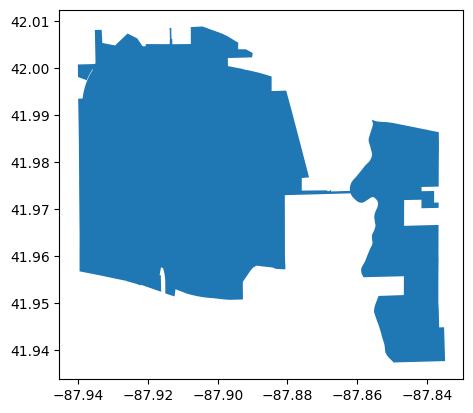

In [6]:
gdf.to_file(DATA_BASE_PATH / "ohare.geojson", driver="GeoJSON")
gdf.plot()

In [7]:
gdf.to_file(DATA_BASE_PATH / "ohare.geojson", driver="GeoJSON")

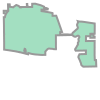

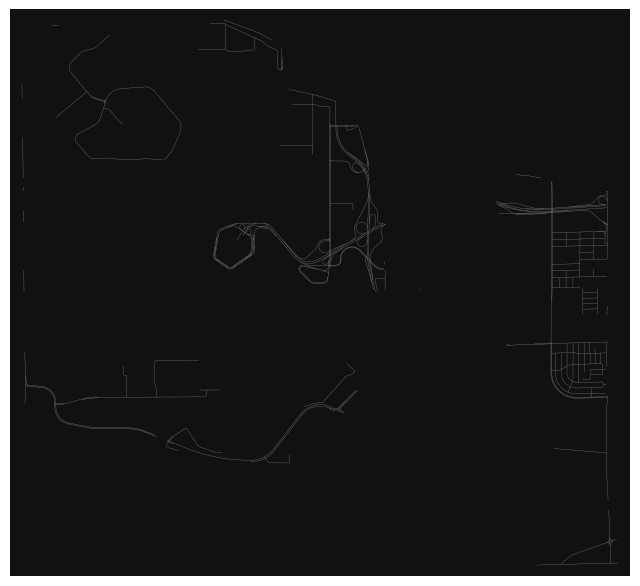

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [8]:
polygon = cast(Polygon, gdf.geometry.iloc[0])
display(polygon)
G = ox.graph_from_polygon(
    polygon, simplify=False, retain_all=True, network_type="drive"
)
ox.plot_graph(G, node_size=0, edge_linewidth=0.2)

In [9]:
ox.save_graph_xml(G, filepath=DATA_BASE_PATH / "ohare_network.osm.xml")